In [ ]:

!pip -q install -U transformers accelerate datasets evaluate
!pip -q install pandas numpy matplotlib seaborn scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.9 MB/s eta 0:00:00


In [ ]:


import torch
import transformers
import pandas as pd
import sklearn
import matplotlib

print("="*50)
print("Torch Version        :", torch.__version__)
print("Transformers Version :", transformers.__version__)
print("Pandas Version       :", pd.__version__)
print("Scikit-Learn Version :", sklearn.__version__)
print("Matplotlib Version   :", matplotlib.__version__)
print("="*50)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("GPU not detected. Running on CPU.")

Torch Version        : 2.11.0+cu128
Transformers Version : 5.14.1
Pandas Version       : 2.2.2
Scikit-Learn Version : 1.6.1
Matplotlib Version   : 3.10.0
Device : cuda
GPU : Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fake_or_real_news.csv to fake_or_real_news.csv


In [ ]:
df = pd.read_csv("fake_or_real_news.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (6335, 4)


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
print(df.isnull().sum())

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


In [ ]:
df = df.dropna()

print(df.shape)

(6335, 4)


In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'title', 'text', 'label']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label
REAL    3171
FAKE    3164
Name: count, dtype: int64


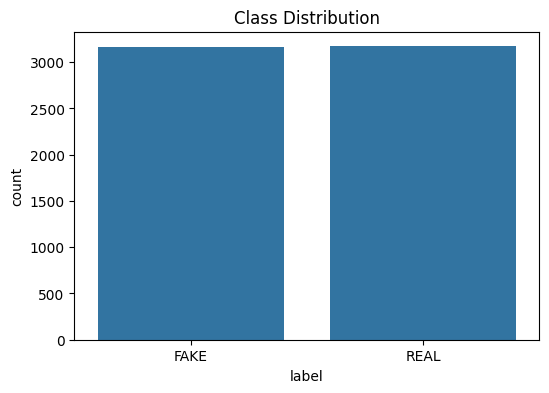

In [ ]:
print(df["label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label")

plt.title("Class Distribution")
plt.show()

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'title', 'text', 'label']


In [ ]:


df["label"] = df["label"].map({
    "FAKE": 0,
    "REAL": 1
})

print(df["label"].value_counts())

label
1    3171
0    3164
Name: count, dtype: int64


In [ ]:


df["content"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("")
)

In [ ]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df["content"] = df["content"].apply(clean_text)

In [ ]:
df = df[["content","label"]]

df.head()

,content,label
0,you can smell hillary s fear daniel greenfield...,0
1,watch the exact moment paul ryan committed pol...,0
2,kerry to go to paris in gesture of sympathy u ...,1
3,bernie supporters on twitter erupt in anger ag...,0
4,the battle of new york why this primary matter...,1


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["content"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Training :", len(train_texts))
print("Validation :", len(val_texts))
print("Testing :", len(test_texts))

Training : 5068
Validation : 633
Testing : 634


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

MAX_LEN = 256

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

print("Tokenization Completed")

Tokenization Completed


In [ ]:
import torch
from torch.utils.data import Dataset

class NewsDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = NewsDataset(
    train_encodings,
    train_labels
)

val_dataset = NewsDataset(
    val_encodings,
    val_labels
)

test_dataset = NewsDataset(
    test_encodings,
    test_labels
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

5068
633
634


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Train Batches : 634
Validation Batches : 80
Test Batches : 80


In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

print("BERT Model Loaded Successfully")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Model Loaded Successfully


In [ ]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

In [ ]:
from transformers import get_linear_schedule_with_warmup

EPOCHS = 10

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [ ]:
best_val_accuracy = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

history = []

In [ ]:


from tqdm.auto import tqdm
import torch

best_val_accuracy = 0

for epoch in range(EPOCHS):

    print("="*60)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("="*60)





    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    loop = tqdm(train_loader)

    for batch in loop:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

        predictions = torch.argmax(logits,dim=1)

        train_correct += (predictions==labels).sum().item()

        train_total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    train_epoch_loss = train_loss/len(train_loader)

    train_epoch_acc = train_correct/train_total




    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader:

            input_ids=batch["input_ids"].to(device)
            attention_mask=batch["attention_mask"].to(device)
            labels=batch["labels"].to(device)

            outputs=model(

                input_ids=input_ids,

                attention_mask=attention_mask,

                labels=labels

            )

            loss=outputs.loss

            logits=outputs.logits

            val_loss+=loss.item()

            predictions=torch.argmax(logits,dim=1)

            val_correct+=(predictions==labels).sum().item()

            val_total+=labels.size(0)

    val_epoch_loss=val_loss/len(val_loader)

    val_epoch_acc=val_correct/val_total




    train_losses.append(train_epoch_loss)
    val_losses.append(val_epoch_loss)

    train_accuracies.append(train_epoch_acc)
    val_accuracies.append(val_epoch_acc)

    history.append({

        "Epoch":epoch+1,

        "Train Loss":train_epoch_loss,

        "Validation Loss":val_epoch_loss,

        "Train Accuracy":train_epoch_acc,

        "Validation Accuracy":val_epoch_acc

    })




    if val_epoch_acc > best_val_accuracy:

        best_val_accuracy = val_epoch_acc

        model.save_pretrained("Best_BERT_Model")

        tokenizer.save_pretrained("Best_BERT_Model")

        print("\nBest Model Saved")



    print(f"\nTrain Loss : {train_epoch_loss:.4f}")

    print(f"Validation Loss : {val_epoch_loss:.4f}")

    print(f"Train Accuracy : {train_epoch_acc:.4f}")

    print(f"Validation Accuracy : {val_epoch_acc:.4f}")

Epoch 1/10


  0%|          | 0/634 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best Model Saved

Train Loss : 0.3027
Validation Loss : 0.1607
Train Accuracy : 0.8856
Validation Accuracy : 0.9573
Epoch 2/10


  0%|          | 0/634 [00:00<?, ?it/s]

...


Best Model Saved

Train Loss : 0.0009
Validation Loss : 0.2602
Train Accuracy : 0.9998
Validation Accuracy : 0.9668
Epoch 9/10


  0%|          | 0/634 [00:00<?, ?it/s]


Train Loss : 0.0000
Validation Loss : 0.2694
Train Accuracy : 1.0000
Validation Accuracy : 0.9668
Epoch 10/10


  0%|          | 0/634 [00:00<?, ?it/s]


Train Loss : 0.0004
Validation Loss : 0.2808
Train Accuracy : 0.9996
Validation Accuracy : 0.9621


In [ ]:
history_df = pd.DataFrame(history)

history_df

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.302657,0.160742,0.885556,0.957346
1,2,0.127337,0.289149,0.971389,0.939968
2,3,0.057286,0.262485,0.989148,0.952607
3,4,0.020457,0.269090,0.995659,0.960506
4,5,0.016080,0.272811,0.997238,0.965245
5,6,0.006542,0.284864,0.998421,0.960506
6,7,0.007034,0.310999,0.998619,0.960506
7,8,0.000870,0.260201,0.999803,0.966825
8,9,0.000014,0.269398,1.000000,0.966825
9,10,0.000435,0.280779,0.999605,0.962085


In [ ]:



model.eval()

test_loss = 0
correct = 0
total = 0

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        test_loss += loss.item()

        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:,1].cpu().numpy())

test_loss = test_loss / len(test_loader)
test_accuracy = correct / total

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.3249
Test Accuracy : 0.9590


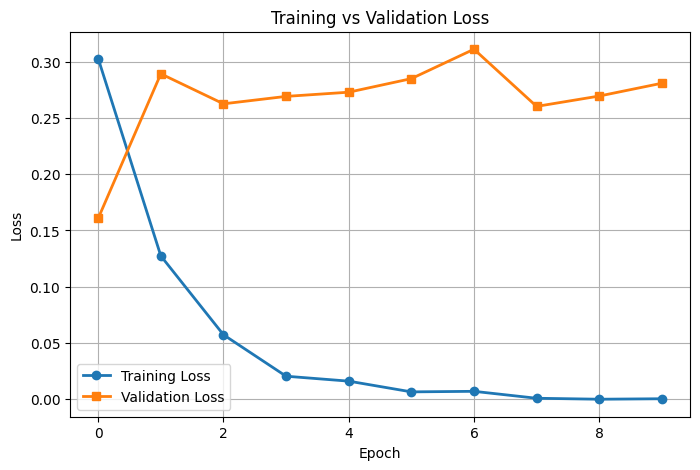

In [ ]:
# ==========================================
# Training vs Validation Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(train_losses,
         marker='o',
         linewidth=2,
         label="Training Loss")

plt.plot(val_losses,
         marker='s',
         linewidth=2,
         label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

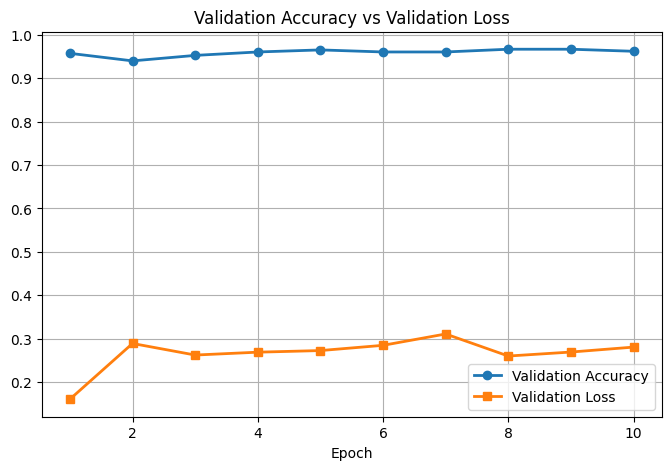

In [ ]:
# ==========================================
# Validation Accuracy vs Validation Loss
# ==========================================

plt.figure(figsize=(8,5))

epochs = range(1, EPOCHS+1)

plt.plot(
    epochs,
    val_accuracies,
    marker='o',
    linewidth=2,
    label="Validation Accuracy"
)

plt.plot(
    epochs,
    val_losses,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.title("Validation Accuracy vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

In [ ]:
print("="*50)
print("Final Test Results")
print("="*50)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Precision     : {precision_score(y_true, y_pred)*100:.2f}%")
print(f"Recall        : {recall_score(y_true, y_pred)*100:.2f}%")
print(f"F1 Score      : {f1_score(y_true, y_pred)*100:.2f}%")

Final Test Results
Test Loss     : 0.3249
Test Accuracy : 95.90%
Precision     : 94.50%
Recall        : 97.48%
F1 Score      : 95.96%


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision :", precision_score(y_true, y_pred))
print("Recall    :", recall_score(y_true, y_pred))
print("F1 Score  :", f1_score(y_true, y_pred))

Precision : 0.944954128440367
Recall    : 0.9747634069400631
F1 Score  : 0.9596273291925466


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("="*50)
print("FINAL TEST RESULTS")
print("="*50)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {accuracy*100:.2f}%")
print(f"Precision      : {precision*100:.2f}%")
print(f"Recall         : {recall*100:.2f}%")
print(f"F1 Score       : {f1*100:.2f}%")

FINAL TEST RESULTS
Test Loss      : 0.3249
Test Accuracy  : 95.90%
Precision      : 94.50%
Recall         : 97.48%
F1 Score       : 95.96%


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["FAKE","REAL"]
))

              precision    recall  f1-score   support

        FAKE       0.97      0.94      0.96       317
        REAL       0.94      0.97      0.96       317

    accuracy                           0.96       634
   macro avg       0.96      0.96      0.96       634
weighted avg       0.96      0.96      0.96       634



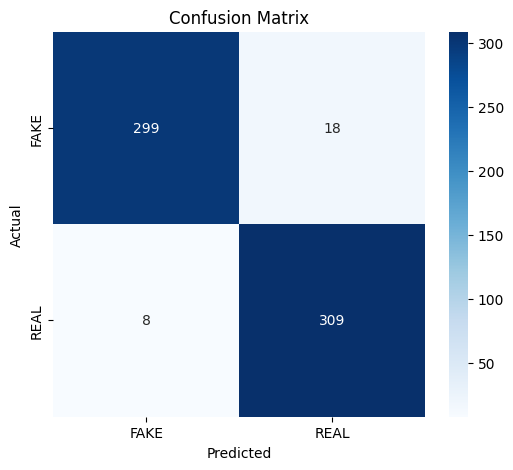

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["FAKE","REAL"],
    yticklabels=["FAKE","REAL"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

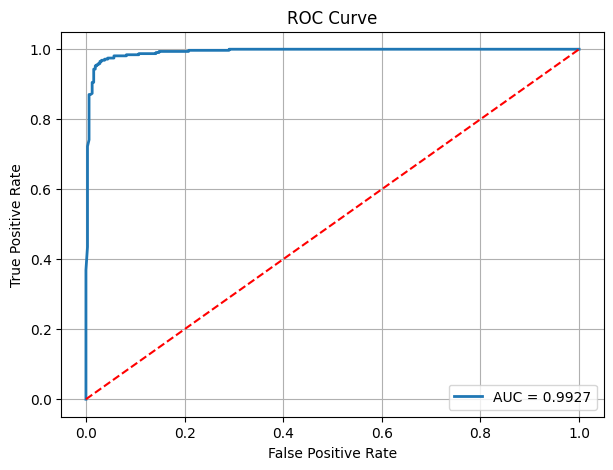

AUC Score : 0.9927454746290639


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print("AUC Score :", roc_auc)

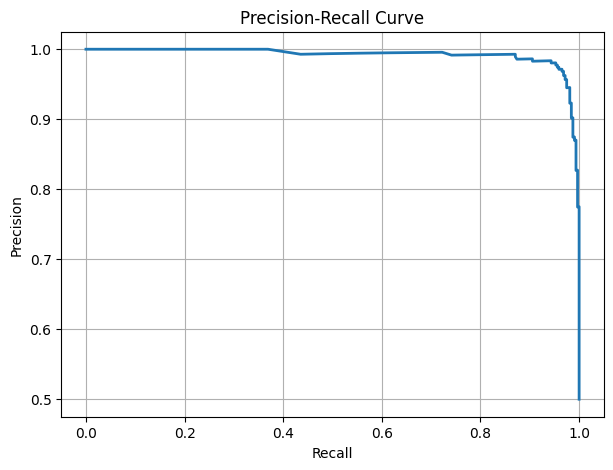

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_true,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

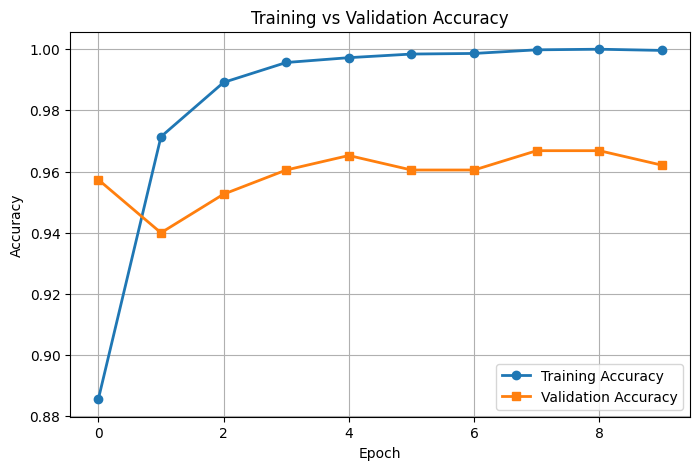

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies,
    marker='o',
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    marker='s',
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

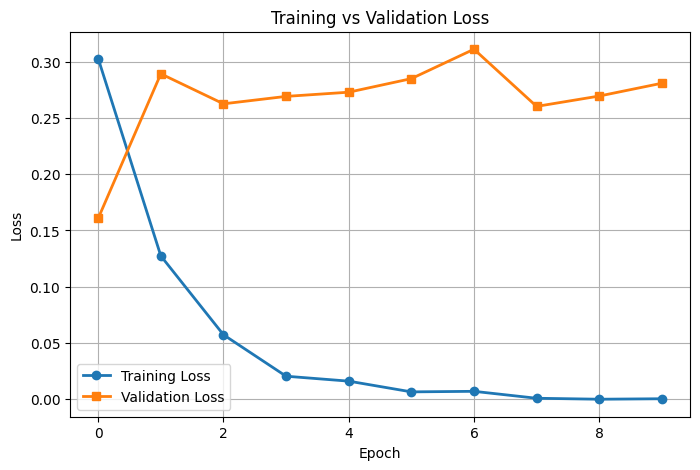

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    val_losses,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig("Training_Validation_Loss.png", dpi=300)

plt.show()

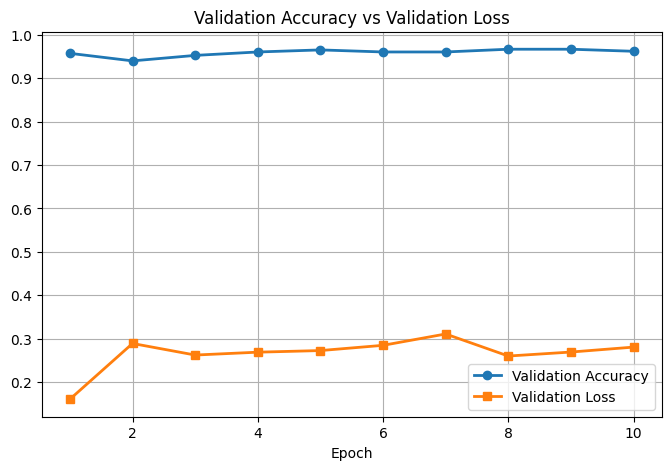

In [ ]:
plt.figure(figsize=(8,5))

epochs = range(1, EPOCHS + 1)

plt.plot(
    epochs,
    val_accuracies,
    marker='o',
    linewidth=2,
    label="Validation Accuracy"
)

plt.plot(
    epochs,
    val_losses,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.title("Validation Accuracy vs Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig("Validation_Accuracy_vs_Loss.png", dpi=300)

plt.show()

In [ ]:
history_df = pd.DataFrame({

    "Epoch": range(1, EPOCHS+1),

    "Train Loss": train_losses,

    "Validation Loss": val_losses,

    "Train Accuracy": train_accuracies,

    "Validation Accuracy": val_accuracies

})

history_df

,Epoch,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy
0,1,0.302657,0.160742,0.885556,0.957346
1,2,0.127337,0.289149,0.971389,0.939968
2,3,0.057286,0.262485,0.989148,0.952607
3,4,0.020457,0.269090,0.995659,0.960506
4,5,0.016080,0.272811,0.997238,0.965245
5,6,0.006542,0.284864,0.998421,0.960506
6,7,0.007034,0.310999,0.998619,0.960506
7,8,0.000870,0.260201,0.999803,0.966825
8,9,0.000014,0.269398,1.000000,0.966825
9,10,0.000435,0.280779,0.999605,0.962085


In [ ]:
history_df.to_csv(
    "Epoch_Wise_Metrics.csv",
    index=False
)

print(history_df)

   Epoch  Train Loss  Validation Loss  Train Accuracy  Validation Accuracy
0      1    0.302657         0.160742        0.885556             0.957346
1      2    0.127337         0.289149        0.971389             0.939968
2      3    0.057286         0.262485        0.989148             0.952607
3      4    0.020457         0.269090        0.995659             0.960506
4      5    0.016080         0.272811        0.997238             0.965245
5      6    0.006542         0.284864        0.998421             0.960506
6      7    0.007034         0.310999        0.998619             0.960506
7      8    0.000870         0.260201        0.999803             0.966825
8      9    0.000014         0.269398        1.000000             0.966825
9     10    0.000435         0.280779        0.999605             0.962085


In [ ]:
misclassified = pd.DataFrame({

    "Actual": y_true,

    "Predicted": y_pred

})

misclassified = misclassified[
    misclassified["Actual"] != misclassified["Predicted"]
]

print("Total Misclassified Samples :", len(misclassified))

misclassified.head(20)

Total Misclassified Samples : 26


,Actual,Predicted
12,0,1
19,0,1
45,1,0
57,0,1
102,0,1
109,0,1
124,0,1
133,1,0
159,0,1
170,0,1


In [ ]:
prediction_examples = pd.DataFrame({

    "Actual": y_true,

    "Predicted": y_pred

})

prediction_examples.head(20)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,1,1
9,0,0


In [ ]:
model.save_pretrained("Final_BERT_Model")

print("Model Saved Successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("Epoch_Wise_Metrics.csv")
files.download("Training_Validation_Loss.png")
files.download("Validation_Accuracy_vs_Loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>